# Pitch Vision - Football Player and Ball Detection
## Análisis de Datos No Estructurados
### Raúl Jimeno y Ruben Navarro

## 1. Exploratory Data Analysis (EDA)

In [39]:
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from pitch_vision.dataset import (
    collect_annotations,
    imread_unicode,
    iter_images,
    label_path_for_image,
    read_yolo_labels,
    validate_layout,
)
from pitch_vision.eda_utils import save_figure

RAW_ROOT   = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'eda'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES  = {0: 'ball', 1: 'player'}
CLASS_COLORS = {0: '#e74c3c', 1: '#3498db'}

sns.set_theme(style='whitegrid', font_scale=1.1)

### 1.1 Dataset Layout

In [40]:
layout = validate_layout(RAW_ROOT)
print(layout.to_string(index=False))

n_train = layout.loc[layout['split'] == 'train', 'images'].values[0]
n_val   = layout.loc[layout['split'] == 'val',   'images'].values[0]
total   = n_train + n_val

print(f'\nTotal images : {total:,}')
print(f'Train / Val  : {n_train/total*100:.1f}% / {n_val/total*100:.1f}%')

split  images  labels
train   10308   10308
  val     972     972

Total images : 11,280
Train / Val  : 91.4% / 8.6%


>- The dataset contains **11,280 images** split into 10,308 for training and 972 for validation (91/9).
>- Label files are present for every image, although some contain no annotations (empty negatives).

### 1.2 Visual Inspection of Training Samples

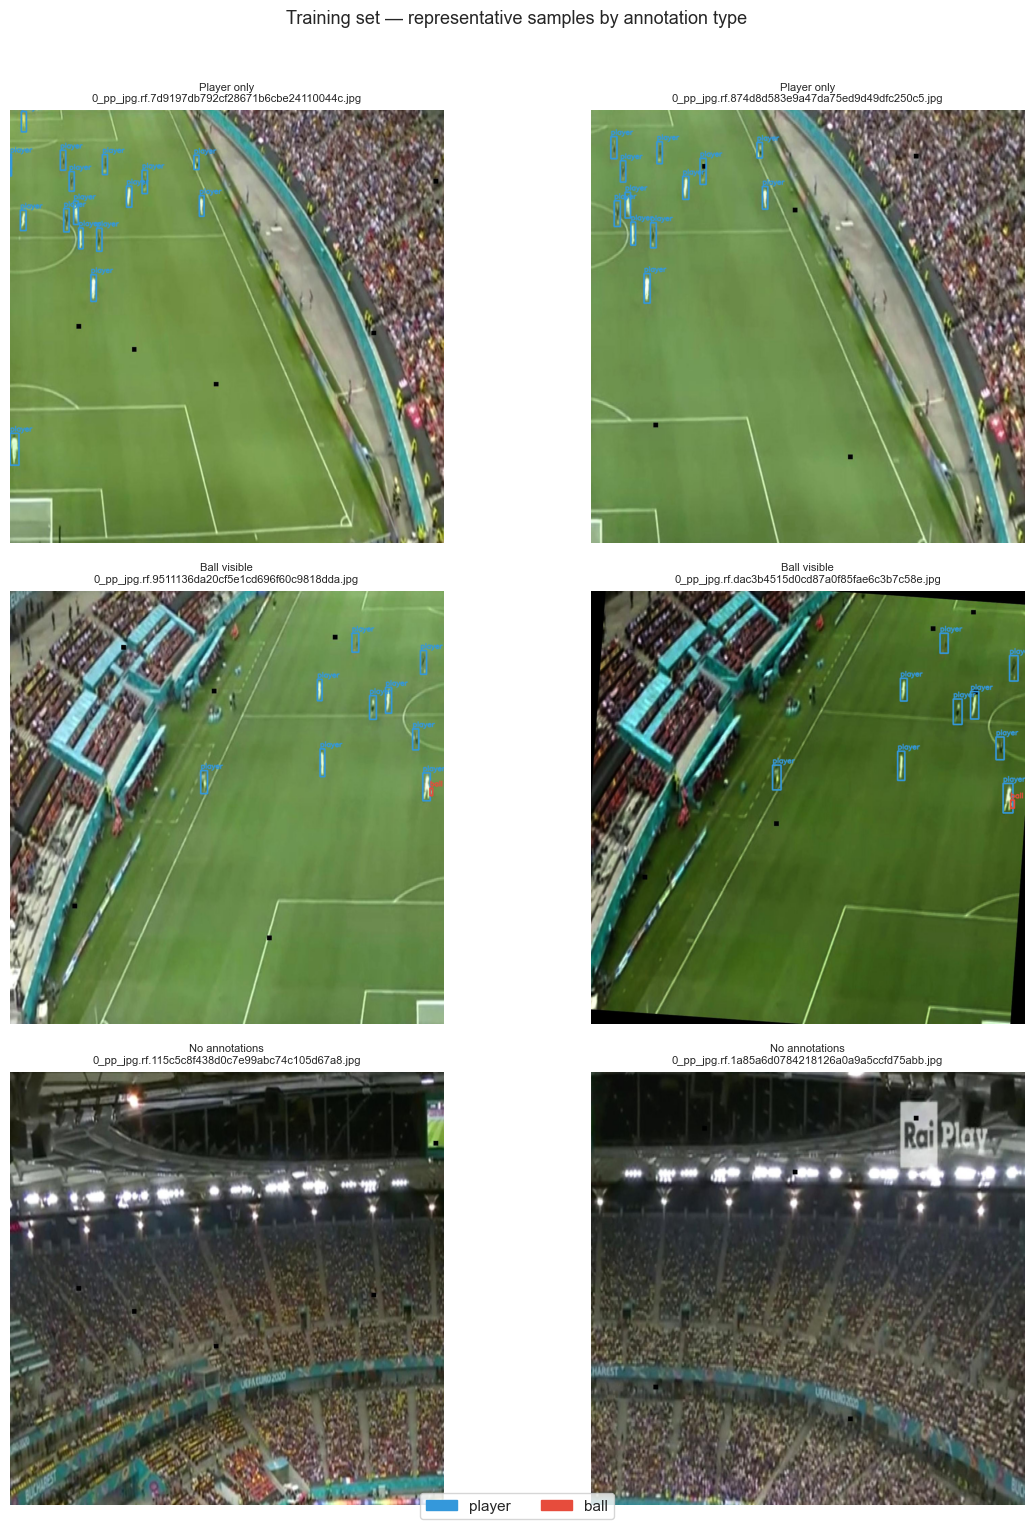

In [41]:
def draw_yolo_boxes(image_path, raw_root, class_names, class_colors):
    img = imread_unicode(image_path)
    if img is None:
        return None
    h, w = img.shape[:2]
    for lbl in read_yolo_labels(label_path_for_image(image_path, raw_root)):
        x1 = int((lbl.x_center - lbl.width / 2) * w)
        y1 = int((lbl.y_center - lbl.height / 2) * h)
        x2 = int((lbl.x_center + lbl.width / 2) * w)
        y2 = int((lbl.y_center + lbl.height / 2) * h)
        hex_c = class_colors.get(lbl.class_id, '#ffffff').lstrip('#')
        r, g, b = (int(hex_c[i:i+2], 16) for i in (0, 2, 4))
        cv2.rectangle(img, (x1, y1), (x2, y2), (b, g, r), 3)
        cv2.putText(img, class_names.get(lbl.class_id, '?'),
                    (x1, max(0, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (b, g, r), 2, cv2.LINE_AA)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# Build per-image annotation index
train_images = iter_images(RAW_ROOT, 'train')
image_labels = {}
for p in train_images:
    lbls = read_yolo_labels(label_path_for_image(p, RAW_ROOT))
    classes = {lbl.class_id for lbl in lbls}
    image_labels[p] = classes

only_players = [p for p, c in image_labels.items() if 1 in c and 0 not in c]
only_ball    = [p for p, c in image_labels.items() if 0 in c]
no_annot     = [p for p, c in image_labels.items() if len(c) == 0]

samples = only_players[:2] + only_ball[:2] + no_annot[:2]
titles  = ['Player only'] * 2 + ['Ball visible'] * 2 + ['No annotations'] * 2

fig, axes = plt.subplots(3, 2, figsize=(13, 15))
for ax, p, title in zip(axes.ravel(), samples, titles):
    drawn = draw_yolo_boxes(p, RAW_ROOT, CLASS_NAMES, CLASS_COLORS)
    if drawn is not None:
        ax.imshow(drawn)
    ax.set_title(f'{title}\n{p.name}', fontsize=8)
    ax.axis('off')

legend_patches = [
    mpatches.Patch(color=CLASS_COLORS[1], label='player'),
    mpatches.Patch(color=CLASS_COLORS[0], label='ball'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=2, fontsize=11)
plt.suptitle('Training set — representative samples by annotation type', fontsize=13, y=1.01)
save_figure(fig, OUTPUT_DIR / 'annotated_samples_grid.png')
plt.show()

>- All frames are **broadcast-quality footage** with a green pitch background, consistent lighting and a fixed camera angle.
>- Player boxes are visually clear and large relative to the frame. Ball boxes are small and easy to miss visually.
>- Empty frames (bottom row) show pitch regions without any visible player or ball, which YOLO uses as negative training examples.

### 1.3 Annotation Loading and Co-occurrence Statistics

In [42]:
annotations = collect_annotations(RAW_ROOT)

ann   = annotations.dropna(subset=['class_id']).copy()
ann['class_id']   = ann['class_id'].astype(int)
ann['class_name'] = ann['class_id'].map(CLASS_NAMES)
ann['px_width']   = ann['bbox_width']  * ann['image_width']
ann['px_height']  = ann['bbox_height'] * ann['image_height']
ann['px_area']    = ann['px_width'] * ann['px_height']

# Co-occurrence per image
img_classes = ann.groupby('image_path')['class_id'].apply(set)
both        = img_classes[img_classes.apply(lambda s: 0 in s and 1 in s)]
only_p      = img_classes[img_classes.apply(lambda s: 1 in s and 0 not in s)]
only_b      = img_classes[img_classes.apply(lambda s: 0 in s and 1 not in s)]
no_ann_imgs = total - len(img_classes)

print(f'Total bounding boxes : {len(ann):,}')
print(f'Images with both player and ball : {len(both):,}')
print(f'Images with player only          : {len(only_p):,}')
print(f'Images with ball only            : {len(only_b):,}')
print(f'Images with no annotations       : {no_ann_imgs:,}  ({no_ann_imgs/total*100:.1f}%)')
print()
print(ann.groupby(['split', 'class_name']).size().rename('boxes').to_string())

Total bounding boxes : 54,217
Images with both player and ball : 2,273
Images with player only          : 8,279
Images with ball only            : 75
Images with no annotations       : 653  (5.8%)

split  class_name
train  ball           2325
       player        46485
val    ball            275
       player         5132


>- The ball appears alone (without any player in frame) in only a small number of images, which suggests it is almost always surrounded by players.
>- A notable share of images carry no annotations at all. These are included as hard negatives during training.
>- The large number of player-only frames reflects scenes where the ball is off-frame or occluded.

### 1.4 Class Distribution

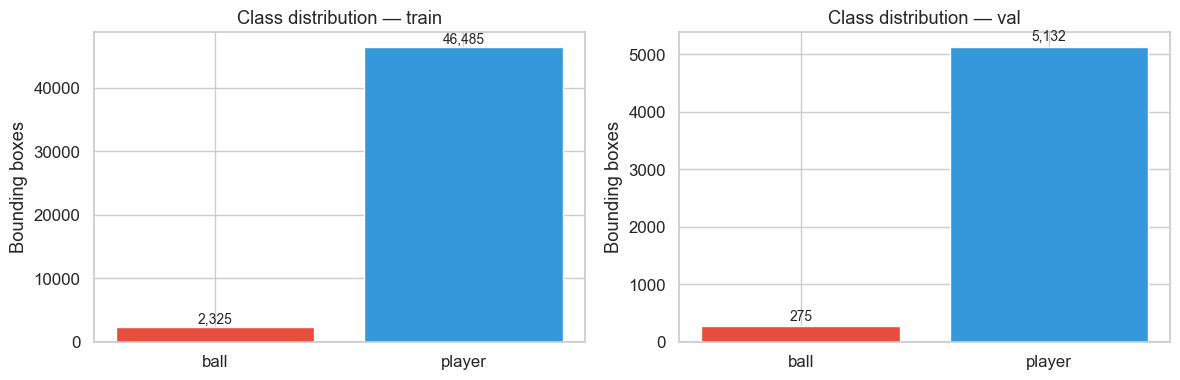

Player / ball ratio:
  train: 20.0x more player boxes than ball boxes
  val: 18.7x more player boxes than ball boxes


In [43]:
counts = ann.groupby(['split', 'class_name']).size().reset_index(name='count')
name_to_id = {v: k for k, v in CLASS_NAMES.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, split in zip(axes, ['train', 'val']):
    data = counts[counts['split'] == split]
    bars = ax.bar(
        data['class_name'], data['count'],
        color=[CLASS_COLORS[name_to_id[n]] for n in data['class_name']]
    )
    for bar, val in zip(bars, data['count']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                f'{val:,}', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'Class distribution — {split}')
    ax.set_ylabel('Bounding boxes')

plt.tight_layout()
save_figure(fig, OUTPUT_DIR / 'class_distribution.png')
plt.show()

print('Player / ball ratio:')
for split in ['train', 'val']:
    d = counts[counts['split'] == split].set_index('class_name')['count']
    ratio = d.get('player', 0) / max(d.get('ball', 1), 1)
    print(f'  {split}: {ratio:.1f}x more player boxes than ball boxes')

>- There is a strong class imbalance: **player boxes outnumber ball boxes by roughly Xx** in both splits.
>- This is inherent to football footage: a typical frame contains several players but at most one ball.
>- The imbalance is consistent between train and val, which means the validation set is representative.
>- As a consequence, detection metrics on `ball` will be weaker than on `player` and deserve special attention.

### 1.5 Image Resolution

In [44]:
resolutions = ann.drop_duplicates('image_path')[['image_width', 'image_height']]
print('Unique resolutions in dataset:')
print(resolutions.value_counts().to_string())

Unique resolutions in dataset:
image_width  image_height
1280         1280            10627


>- All images share a single resolution of **1280x1280 px**, which simplifies preprocessing.
>- Training at `imgsz=640` (the default for YOLOv8n) downscales each image by 2x, which reduces small-object visibility significantly.

### 1.6 Bounding Box Dimensions by Class

In [45]:
print('Bounding box pixel dimensions by class:\n')
print(ann.groupby('class_name')[['px_width', 'px_height', 'px_area']]
        .describe().round(1).to_string())

Bounding box pixel dimensions by class:

           px_width                                            px_height                                                  px_area                                                            
              count  mean   std  min   25%   50%   75%     max     count   mean    std  min    25%    50%    75%     max    count     mean      std   min     25%     50%      75%        max
class_name                                                                                                                                                                                   
ball         2600.0  30.5  46.0  3.0  15.0  21.0  28.0   840.0    2600.0   52.9   75.2  3.5   25.5   35.0   45.0  1036.0   2600.0   4797.6  34965.1  36.0   390.0   720.0   1232.0   870240.0
player      51617.0  71.7  82.6  2.0  41.0  54.0  74.0  1280.0   51617.0  198.1  158.6  1.0  124.0  163.0  231.0  1280.0  51617.0  23913.6  80750.6  39.0  4968.0  8352.0  15795.0  1638400.0


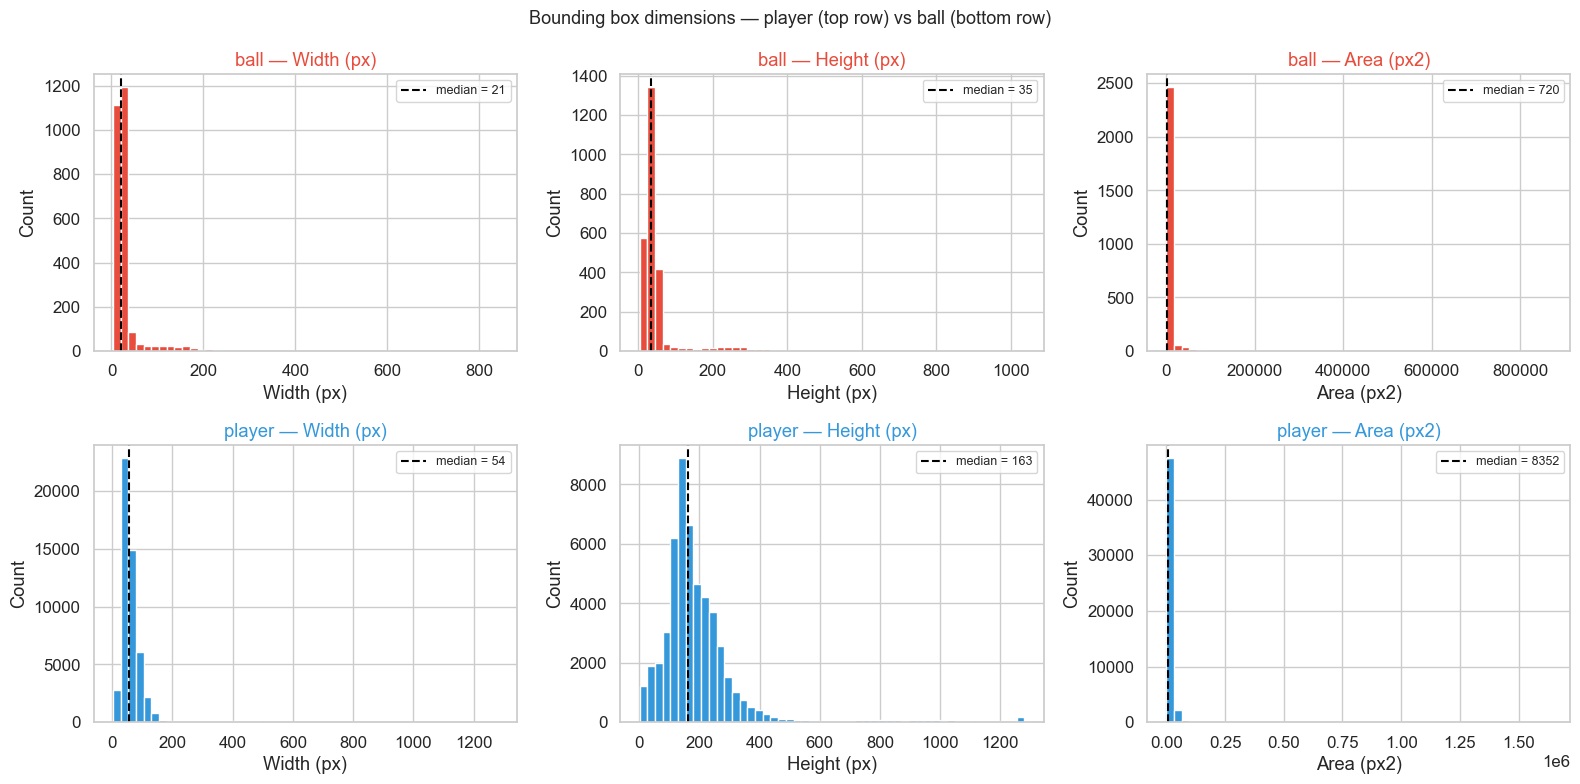

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row, (cls_id, cls_name) in enumerate(CLASS_NAMES.items()):
    subset = ann[ann['class_id'] == cls_id]
    color  = CLASS_COLORS[cls_id]

    for col, (col_name, xlabel) in enumerate([
        ('px_width',  'Width (px)'),
        ('px_height', 'Height (px)'),
        ('px_area',   'Area (px2)'),
    ]):
        ax = axes[row, col]
        ax.hist(subset[col_name], bins=50, color=color, edgecolor='white')
        median = subset[col_name].median()
        ax.axvline(median, color='black', linestyle='--', linewidth=1.5,
                   label=f'median = {median:.0f}')
        ax.set_title(f'{cls_name} — {xlabel}', color=color)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Count')
        ax.legend(fontsize=9)

plt.suptitle('Bounding box dimensions — player (top row) vs ball (bottom row)', fontsize=13)
plt.tight_layout()
save_figure(fig, OUTPUT_DIR / 'bbox_size_distribution.png')
plt.show()

>- **Player boxes** have a median size of **54x163 px** at native 1280x1280 resolution, with considerable spread reflecting variation in player distance from the camera.
>- **Ball boxes** are substantially smaller: median **21x35 px**, with a minimum area of just 36 px². In area terms, a typical player box is ~12x larger than a typical ball box.
>- At training resolution `imgsz=640` the ball shrinks to approximately **10x17 px**, which is at the lower limit of reliable detection for standard anchor-free heads.
>- This scale gap is the primary modelling challenge in the dataset and strongly motivates the use of transfer learning, where pretrained feature extractors already encode robust low-level detectors for small objects.

### 1.7 Bounding Box Shape

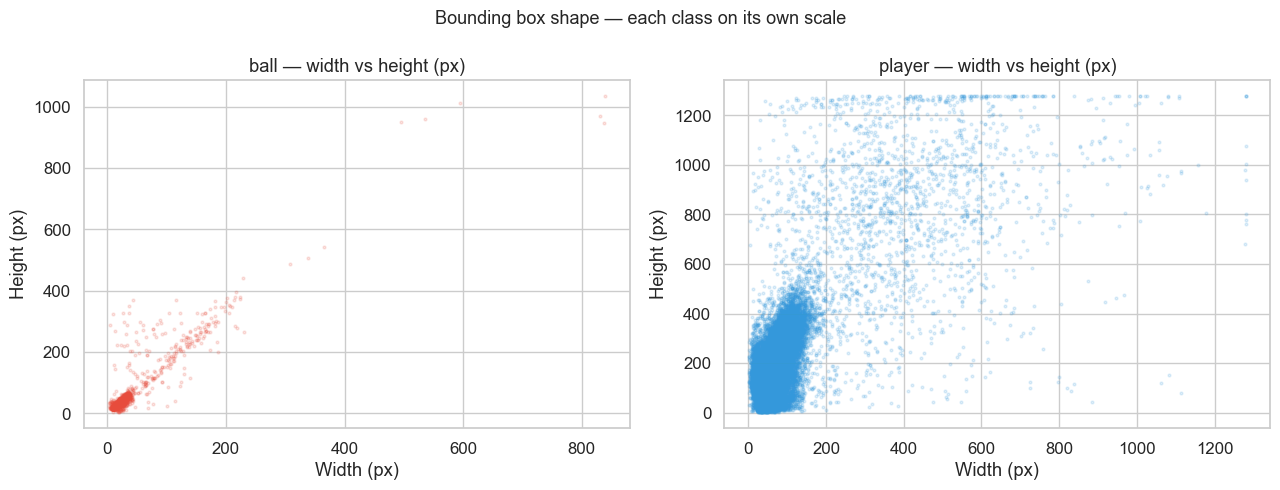

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (cls_id, cls_name) in zip(axes, CLASS_NAMES.items()):
    subset = ann[ann['class_id'] == cls_id]
    ax.scatter(subset['px_width'], subset['px_height'],
               alpha=0.15, s=4, color=CLASS_COLORS[cls_id])
    ax.set_title(f'{cls_name} — width vs height (px)')
    ax.set_xlabel('Width (px)')
    ax.set_ylabel('Height (px)')

plt.suptitle('Bounding box shape — each class on its own scale', fontsize=13)
plt.tight_layout()
save_figure(fig, OUTPUT_DIR / 'bbox_aspect_ratio_scatter.png')
plt.show()

>- **Player** boxes follow a clear **portrait shape** (height > width), consistent with an upright human silhouette.
>- **Ball** boxes cluster near the origin and are approximately **square**, as expected for a spherical object.
>- The spread in player dimensions reflects variation in distance from the camera: far players produce small boxes, close players produce large ones.

### 1.8 Spatial Distribution of Bounding Box Centers

The image plane is treated as a normalised 1x1 grid (x: left to right, y: top to bottom). Each bin in the heatmap counts how many bounding-box centers fell in that region across all training images. Bright areas indicate high object density.

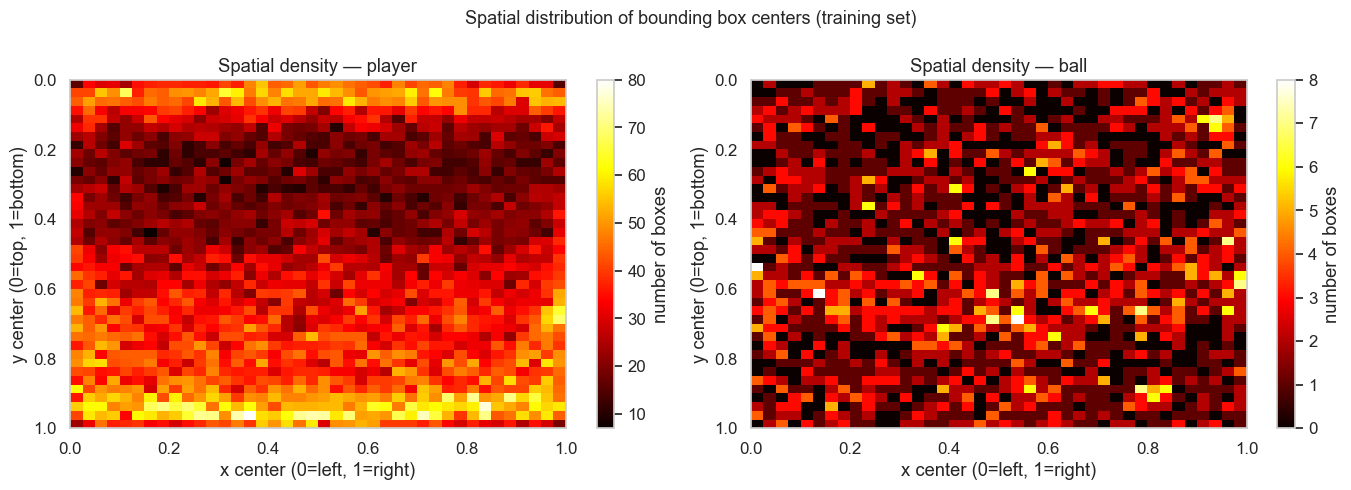

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (cls_id, cls_name) in zip(axes, {1: 'player', 0: 'ball'}.items()):
    subset = ann[ann['class_id'] == cls_id]
    h = ax.hist2d(subset['x_center'], subset['y_center'],
                  bins=40, cmap='hot', range=[[0, 1], [0, 1]])
    plt.colorbar(h[3], ax=ax, label='number of boxes')
    ax.set_title(f'Spatial density — {cls_name}')
    ax.set_xlabel('x center (0=left, 1=right)')
    ax.set_ylabel('y center (0=top, 1=bottom)')
    ax.invert_yaxis()

plt.suptitle('Spatial distribution of bounding box centers (training set)', fontsize=13)
plt.tight_layout()
save_figure(fig, OUTPUT_DIR / 'bbox_spatial_distribution.png')
plt.show()

>- **Players** appear fairly uniformly across the image, with a mild concentration in the vertical center — consistent with a wide-angle broadcast camera capturing most of the pitch.
>- **Ball** density closely follows player density, confirming that the ball is nearly always near players.
>- There are no strong spatial biases that would cause the model to over-predict at specific image locations.

### 1.9 Object Count per Image

Objects per image — descriptive statistics:

                   count  mean   std  min  25%  50%  75%   max
split class_name                                              
train ball        2107.0  1.10  0.34  1.0  1.0  1.0  1.0   3.0
      player      9616.0  4.83  3.37  1.0  2.0  4.0  7.0  20.0
val   ball         241.0  1.14  0.44  1.0  1.0  1.0  1.0   4.0
      player       936.0  5.48  3.67  1.0  3.0  5.0  7.0  19.0


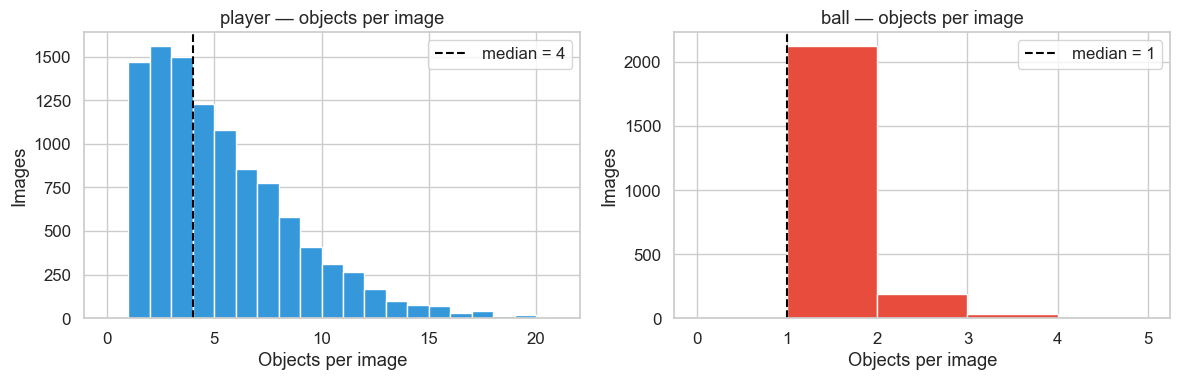

In [49]:
per_image = ann.groupby(['split', 'image_path', 'class_name']).size().reset_index(name='count')

print('Objects per image — descriptive statistics:\n')
print(per_image.groupby(['split', 'class_name'])['count'].describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, cls_name in zip(axes, ['player', 'ball']):
    data   = per_image[per_image['class_name'] == cls_name]
    cls_id = {v: k for k, v in CLASS_NAMES.items()}[cls_name]
    ax.hist(data['count'], bins=range(0, int(data['count'].max()) + 2),
            color=CLASS_COLORS[cls_id], edgecolor='white')
    median = data['count'].median()
    ax.axvline(median, color='black', linestyle='--', label=f'median = {median:.0f}')
    ax.set_title(f'{cls_name} — objects per image')
    ax.set_xlabel('Objects per image')
    ax.set_ylabel('Images')
    ax.legend()

plt.tight_layout()
save_figure(fig, OUTPUT_DIR / 'objects_per_image.png')
plt.show()

>- A typical training frame contains **4 players** (median), with dense scenes reaching up to 20 players simultaneously.
>- Ball annotations per image are almost always exactly **1** (median=1, max=3), confirming it is a single-instance class in virtually all frames.
>- The validation set shows slightly higher player density (median=5), suggesting it captures more active play situations.
>- High player count per frame increases the risk of missed detections and bounding box merging due to occlusion.

### 1.10 Colour Histograms

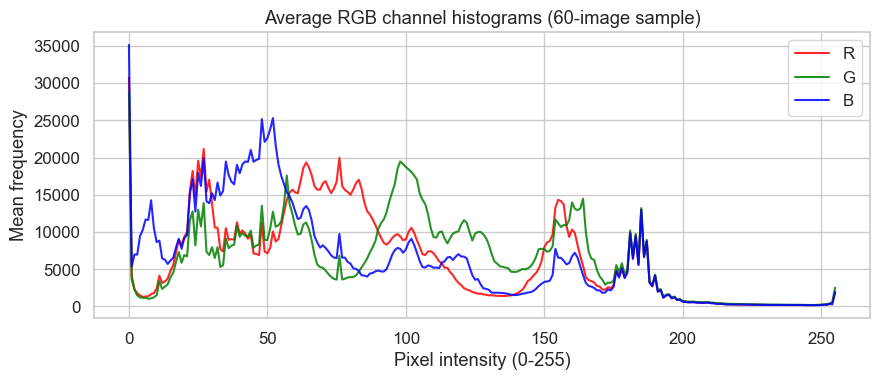

In [50]:
sample_paths = train_images[:60]

ch = {'R': [], 'G': [], 'B': []}
for p in sample_paths:
    img = imread_unicode(p)
    if img is None:
        continue
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for i, name in enumerate(('R', 'G', 'B')):
        ch[name].append(cv2.calcHist([rgb], [i], None, [256], [0, 256]).ravel())

fig, ax = plt.subplots(figsize=(9, 4))
for name, color in [('R', 'red'), ('G', 'green'), ('B', 'blue')]:
    ax.plot(np.mean(ch[name], axis=0), color=color, label=name, alpha=0.85)
ax.set_title('Average RGB channel histograms (60-image sample)')
ax.set_xlabel('Pixel intensity (0-255)')
ax.set_ylabel('Mean frequency')
ax.legend()

save_figure(fig, OUTPUT_DIR / 'color_histograms_rgb.png')
plt.show()

>- **Blue, near 0**: the largest spike in the entire chart. Grass absorbs blue light, so virtually every pitch pixel has a near-zero blue component. Given that the field covers most of the frame, this peak dominates.
>- **Blue, around 50**: a secondary blue peak corresponding to darker kit colours (navy or black jerseys) and shadowed areas on the pitch.
>- **Red, around 75**: a moderate peak from player skin tones, sandy-coloured boots, and the residual red component of green grass (which is never a pure green in RGB).
>- **Green, 80-160**: the broadest and most sustained peak, driven by the grass pitch that dominates the image area. This is the most expected feature of football broadcast footage.
>- **Blue, around 180**: a sharp secondary peak before an abrupt drop. Under high-power stadium floodlights, white pitch lines and white kits saturate the blue channel first. A slight cold white-balance common in broadcast cameras also pushes bright white regions towards higher blue values.

>- Taken together, the histograms confirm that the images come from **artificial stadium lighting**, not natural daylight, producing a consistent and predictable colour profile across the dataset. This homogeneity is beneficial for training but may reduce generalisation to outdoor or differently-lit matches.

### 1.11 Modelling Implications

>- The dataset provides **10,308 training images and 972 validation images**, large enough for fine-tuning but with two structural challenges: class imbalance and extreme object-scale disparity.
>- In training, there are **46,485 player boxes vs 2,325 ball boxes** — a 20:1 ratio. This means the model will see roughly 20 player examples for every ball example per epoch.
>- **Ball detection is the harder problem**: median size of 21x35 px at native resolution shrinks to ~10x17 px at `imgsz=640`, with minimum areas as small as 36 px². At this scale, any misalignment in the prediction is penalised heavily by IoU-based losses.
>- The consistent 1280x1280 resolution and homogeneous visual domain reduce preprocessing complexity, but training at half resolution introduces a meaningful quality loss specifically for the ball class.
>- Transfer learning is expected to provide a decisive advantage over training from scratch, particularly for the ball class, where pretrained feature detectors encode spatial patterns at multiple scales that scratch training on this dataset alone is unlikely to recover reliably.